### 1. EDA 1차 훑어보기

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)


In [5]:
# 10월 데이터
df_110 = pd.read_csv("data/01.카드_회원정보_combined/201810_회원정보.csv")
df_210 = pd.read_csv("data/02.카드_신용정보_combined/201810_신용정보.csv")
df_310 = pd.read_csv("data/03.카드_승인매출정보_combined/201810_승인매출정보.csv")
df_510 = pd.read_csv("data/05.카드_잔액정보_combined/201810_잔액정보.csv")
df_810 = pd.read_csv("data/08.카드_성과정보_combined/201810_성과정보.csv")

# 11월 잔액 (타겟용)
df_511 = pd.read_csv("artifacts/train_data.csv")


In [7]:
df_510.columns[:10]
df_511.columns[:10]


Index(['발급회원번호', '남녀구분코드', '연령', 'VIP등급코드', '최상위카드등급코드', '회원여부_이용가능',
       '회원여부_이용가능_CA', '회원여부_이용가능_카드론', '소지여부_신용', '회원여부_연체'],
      dtype='object')

### RV 사용 고객 추출

In [8]:
# RV 이월 잔액이 0보다 큰 고객만 (10월 기준)
df_510_rv = df_510[df_510['잔액_리볼빙일시불이월_B0M'] > 0].copy()

# 분석에 쓸 키 + 기본 컬럼
df_510_rv_sub = df_510_rv[['발급회원번호', '잔액_리볼빙일시불이월_B0M']]


### 신용정보

In [10]:
df_210_sub = df_210[[
    '발급회원번호',
    'RV약정청구율', 'RV최소결제비율', '카드이용한도금액'
]]

### 승인매출정보

In [11]:
df_310_sub = df_310[[
    '발급회원번호',
    '이용금액_일시불_B0M',
    '이용금액_신용_B0M',
    '이용건수_신용_B0M'
]]

### 성과정보

In [12]:
df_810_sub = df_810[[
    '발급회원번호',
    '잔액_신판평균한도소진율_r6m'
]]

### 11월 타켓 변수 추출

In [13]:
target_col = '잔액_리볼빙일시불이월_B0M'
df_511[target_col].head()

0    1512611
1    1139341
2    1936044
3     894886
4    1024403
Name: 잔액_리볼빙일시불이월_B0M, dtype: int64

In [15]:
df_511_target = df_511[['발급회원번호', target_col]]

### 1주차 과제에서 진행했던 주요 변수 모으기

In [16]:
df_factors1 = df_510_rv_sub.copy()

# 신용정보 붙이기
df_factors1 = df_factors1.merge(
    df_210_sub, on=['발급회원번호'], how='left'
)

# 승인/이용 붙이기
df_factors1 = df_factors1.merge(
    df_310_sub, on=['발급회원번호'], how='left'
)

# 성과정보 붙이기
df_factors1 = df_factors1.merge(
    df_810_sub, on=['발급회원번호'], how='left'
)


df_factors1 = df_factors1.merge(
    df_511_target,
    on='발급회원번호',     
    how='left',
    suffixes=('', '_11월')
)


In [18]:
df_factors1.head()
# df_factors1.columns
# df_factors1[target_col].describe()


,발급회원번호,잔액_리볼빙일시불이월_B0M,RV약정청구율,RV최소결제비율,카드이용한도금액,이용금액_일시불_B0M,이용금액_신용_B0M,이용건수_신용_B0M,잔액_신판평균한도소진율_r6m,잔액_리볼빙일시불이월_B0M_11월
0,SYN_108,1512611,20.912946,10.0,4209755,530723,1371569,7,0.469525,1512611
1,SYN_116,1139341,20.492362,10.0,387324,0,0,0,0.847372,1139341
2,SYN_130,1936044,19.625443,20.0,8638043,134267,848926,9,0.746399,1936044
3,SYN_214,894886,100.000000,20.0,8792092,336233,1092614,10,0.022702,894886
4,SYN_227,1024403,22.855123,20.0,5140724,705905,1823372,31,0.272367,1024403


### 앞선 작업이 데이터 불러오기 및 확인 과정

--------------------------------------------------------------------------------------------------------------------------

### 이후 작업이 EDA 들어가기

In [19]:
target_col = '잔액_리볼빙일시불이월_B0M_11월'

cols = [
    '잔액_리볼빙일시불이월_B0M',        # 10월 RV잔액
    'RV약정청구율',
    'RV최소결제비율',
    '카드이용한도금액',
    '이용금액_일시불_B0M',
    '이용금액_신용_B0M',
    '이용건수_신용_B0M',
    '잔액_신판평균한도소진율_r6m',
    target_col
]

df_eda = df_factors1[cols].copy()


In [20]:
# 결측 비율
df_eda.isna().mean().sort_values(ascending=False)

잔액_리볼빙일시불이월_B0M        0.0
RV약정청구율                0.0
RV최소결제비율               0.0
카드이용한도금액               0.0
이용금액_일시불_B0M           0.0
이용금액_신용_B0M            0.0
이용건수_신용_B0M            0.0
잔액_신판평균한도소진율_r6m       0.0
잔액_리볼빙일시불이월_B0M_11월    0.0
dtype: float64

In [21]:
# 기초 통계

pd.set_option('display.float_format', '{:,.2f}'.format)

df_eda.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,99%,max
잔액_리볼빙일시불이월_B0M,"83,403.00","1,282,027.80","415,298.17","380,876.00","965,844.00","1,262,408.00","1,555,531.50","1,831,275.40","2,343,695.32","3,750,693.00"
RV약정청구율,"83,403.00",37.95,32.52,0.00,20.31,21.41,23.29,100.00,100.00,100.00
RV최소결제비율,"83,403.00",15.80,4.84,0.00,10.00,20.00,20.00,20.00,25.00,30.00
카드이용한도금액,"83,403.00","5,167,838.19","4,125,971.91",0.00,"2,030,977.50","4,576,159.00","5,512,088.00","8,944,502.60","20,432,569.32","23,925,978.00"
이용금액_일시불_B0M,"83,403.00","433,805.64","391,780.10","-217,191.00","162,649.50","342,284.00","601,112.00","962,874.40","1,772,555.34","2,951,751.00"
이용금액_신용_B0M,"83,403.00","736,950.55","620,794.96","-183,764.00","261,157.50","592,313.00","1,068,606.50","1,630,842.20","2,609,724.40","4,333,010.00"
이용건수_신용_B0M,"83,403.00",19.78,20.45,-3.00,4.00,13.00,30.00,52.00,78.00,88.00
잔액_신판평균한도소진율_r6m,"83,403.00",0.52,0.23,0.00,0.34,0.56,0.72,0.80,0.88,0.97
잔액_리볼빙일시불이월_B0M_11월,"83,403.00","1,282,027.80","415,298.17","380,876.00","965,844.00","1,262,408.00","1,555,531.50","1,831,275.40","2,343,695.32","3,750,693.00"


### 수치형 분포

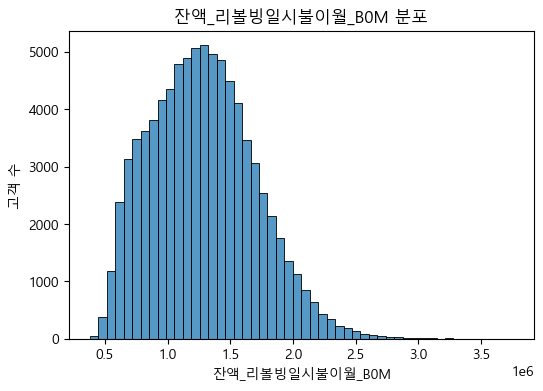

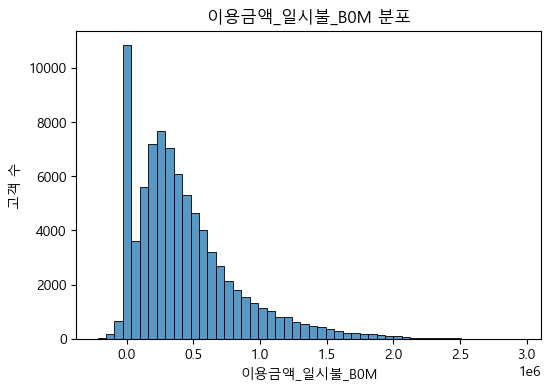

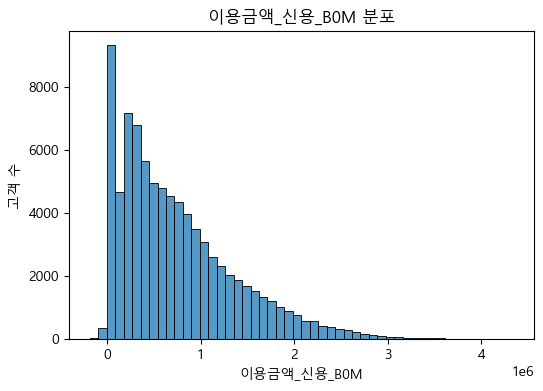

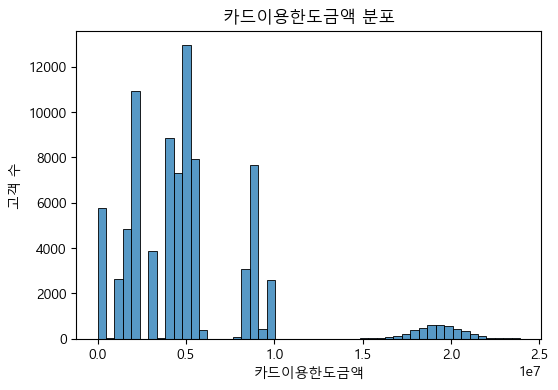

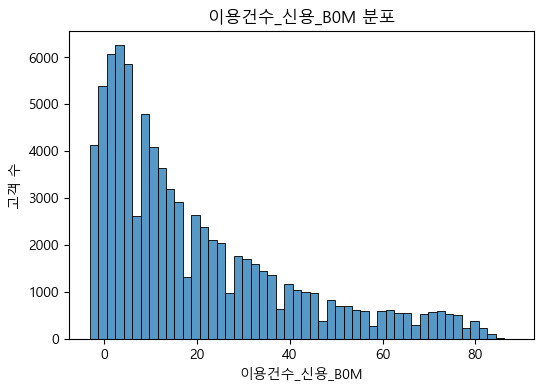

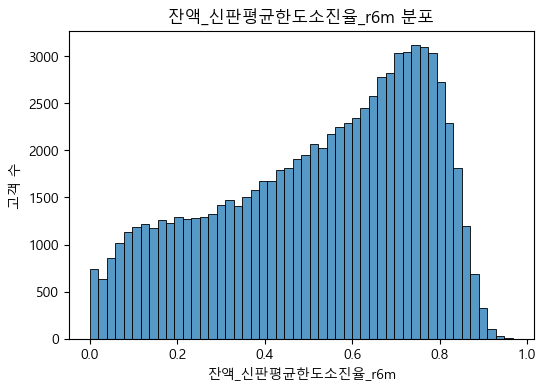

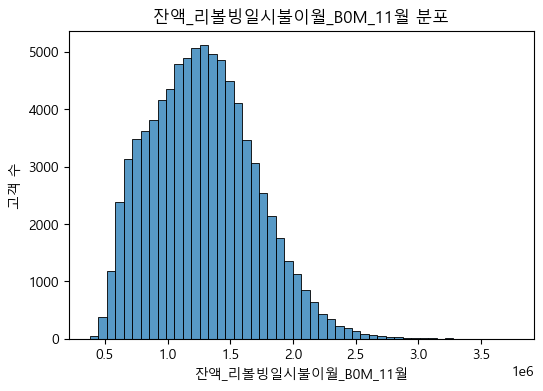

In [22]:
num_cols = [
    '잔액_리볼빙일시불이월_B0M',
    '이용금액_일시불_B0M',
    '이용금액_신용_B0M',
    '카드이용한도금액',
    '이용건수_신용_B0M',
    '잔액_신판평균한도소진율_r6m',
    target_col
]

for c in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_eda[c].dropna(), bins=50)
    plt.title(f'{c} 분포')
    plt.xlabel(c)
    plt.ylabel('고객 수')
    plt.show()


### 약정 분포 비율

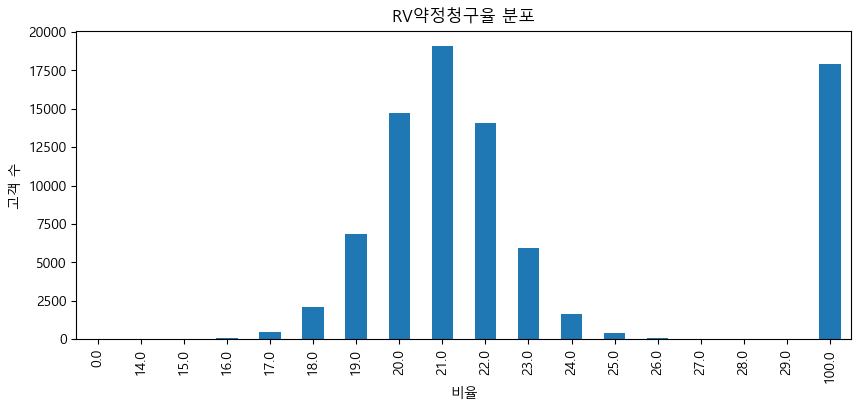

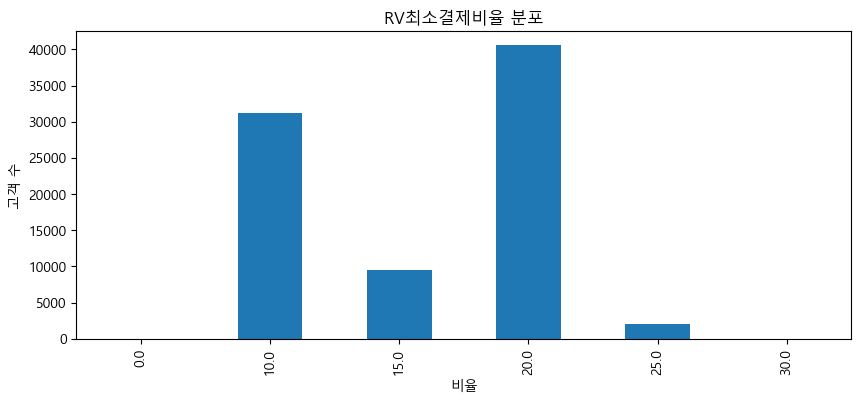

In [23]:
for c in ['RV약정청구율', 'RV최소결제비율']:
    plt.figure(figsize=(10,4))
    tmp = df_eda[c].round(0)   # 숫자를 0자리까지 반올림하여 축 단순화
    tmp.value_counts().sort_index().plot(kind='bar')
    plt.title(f'{c} 분포')
    plt.xlabel('비율')
    plt.ylabel('고객 수')
    plt.show()


### 11월 타겟 데이터 분포 확인

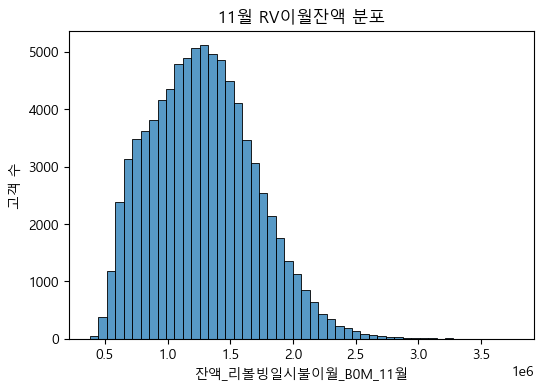

In [24]:
target_col = '잔액_리볼빙일시불이월_B0M_11월'

s = df_eda[target_col].fillna(0)

plt.figure(figsize=(6,4))
sns.histplot(s[s > 0], bins=50)
plt.title('11월 RV이월잔액 분포')
plt.xlabel(target_col)
plt.ylabel('고객 수')
plt.show()


------------------------------------------------------------------------------------------------------------------------------------

### 2. 통계적으로 유의미한 변수 찾기

In [26]:
oct_feats = [
    '잔액_리볼빙일시불이월_B0M',   # 10월 RV 이월잔액
    'RV약정청구율',
    'RV최소결제비율',
    '카드이용한도금액',
    '이용금액_일시불_B0M',
    '이용금액_신용_B0M',
    '이용건수_신용_B0M',
    '잔액_신판평균한도소진율_r6m'
]

df_oct = df_eda[oct_feats].copy()


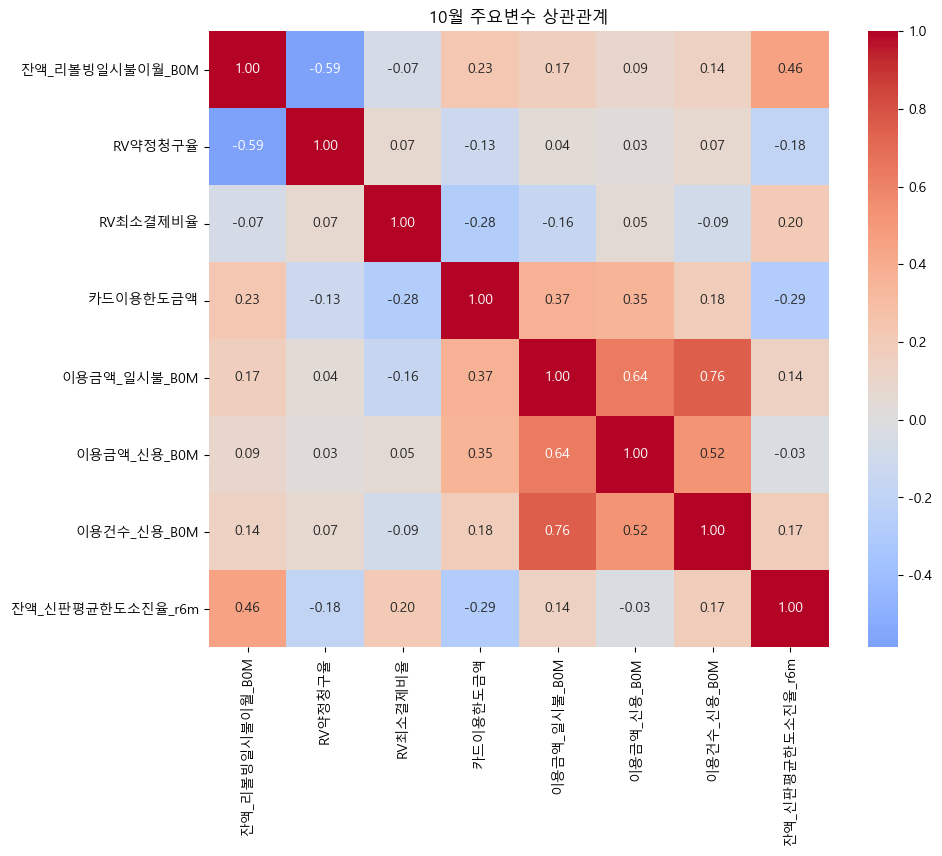

In [27]:
plt.figure(figsize=(10, 8))
corr = df_oct.corr()
sns.heatmap(corr, annot=True,fmt='.2f', cmap='coolwarm', center=0)
plt.title('10월 주요변수 상관관계')
plt.show()


### 히트맵에서 보이는 것들 : 

### *약정청구율이 낮을수록 10월 RV일시불잔액이 많은 편이다. 
### *한도소진율이 높은 고객일수록 10월 RV일시불잔액이 많은 편이다. (관계성이 강하지는 않음)

------------------------------------------------------------------------------------------------------------------------------------

### 위에서 찾은 두 관계 조금 더 자세히 알아보기
### 1. 약정청구율 - 잔액_리볼빙일시불이월_B0M  

C:\Users\jongy\AppData\Local\Temp\ipykernel_5088\359185279.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df_oct.groupby('약정구간')[target].agg(['count','mean','median'])


,count,mean,median
약정구간,,,
0%,8,"887,683.00","812,102.00"
1~10%,0,NaN,NaN
10~20%,15890,"1,698,690.12","1,685,863.50"
20~50%,49558,"1,311,825.39","1,293,340.50"
50~100%,17947,"831,015.43","786,601.00"


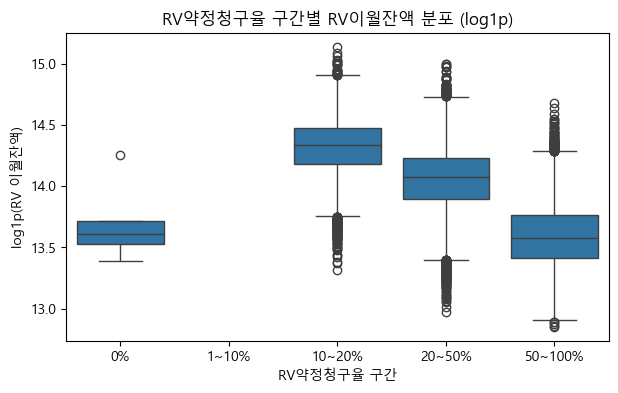

In [29]:
target = '잔액_리볼빙일시불이월_B0M'
rate_col = 'RV약정청구율'

df_oct[target] = df_oct[target].fillna(0)

# RV약정청구율 구간 나누기 (버킷)
bins = [0, 1, 10, 20, 50, 101]  
labels = ['0%', '1~10%', '10~20%', '20~50%', '50~100%']

df_oct['약정구간'] = pd.cut(df_oct[rate_col], bins=bins, labels=labels, include_lowest=True)

# 구간별 통계
bucket_stats = df_oct.groupby('약정구간')[target].agg(['count','mean','median'])
display(bucket_stats)

# 박스플롯
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_oct,
    x='약정구간',
    y=np.log1p(df_oct[target])
)
plt.title('RV약정청구율 구간별 RV이월잔액 분포 (log1p)')
plt.xlabel('RV약정청구율 구간')
plt.ylabel('log1p(RV 이월잔액)')
plt.show()


### *그림을 그려보니까 당연하다는 걸 깨달았습니다,, 
### *청구율이 높으면 많이 갚으니까 남은 이월 잔액이 적어질 수 밖에 없네요,,

------------------------------------------------------------------------------------------------------------------------------------

### 2. 잔액_신판한도소진율 - 잔액_리볼빙일시불이월_B0M

### 한도소진율_r6m을 기준으로 3그룹으로 나눠서 10월 RV 이월잔액 비교 + @(이용금액, 카드이용한도)

In [34]:
bins = [0, 0.5, 0.8, 1.5]
labels = ['저소진(≤50%)', '중간소진(50~80%)', '고소진(>80%)']

df_oct['소진율_그룹'] = pd.cut(df_oct['잔액_신판평균한도소진율_r6m'],
                          bins=bins, labels=labels, include_lowest=True)


In [36]:
group_stats = df_oct.groupby('소진율_그룹')[[
    '잔액_리볼빙일시불이월_B0M',
    '이용금액_신용_B0M',
    '이용금액_일시불_B0M',
    '카드이용한도금액'
]].agg(['mean','median','count'])

group_stats


C:\Users\jongy\AppData\Local\Temp\ipykernel_5088\1397284669.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df_oct.groupby('소진율_그룹')[[


잔액_리볼빙일시불이월_B0M                     이용금액_신용_B0M             \
                        mean       median  count        mean     median   
소진율_그룹                                                                    
저소진(≤50%)       1,093,416.63 1,078,508.00  34831  773,224.09 587,592.00   
중간소진(50~80%)    1,393,797.35 1,403,173.00  40411  751,661.19 640,431.00   
고소진(>80%)       1,533,565.14 1,529,936.00   8161  509,292.77 410,265.00   

                    이용금액_일시불_B0M                       카드이용한도금액               \
              count         mean     median  count         mean       median   
소진율_그룹                                                                         
저소진(≤50%)     34831   378,985.11 287,638.00  34831 6,323,277.10 5,109,423.00   
중간소진(50~80%)  40411   484,907.61 394,354.00  40411 4,566,038.50 4,276,955.00   
고소진(>80%)      8161   414,735.91 347,133.00   8161 3,216,390.36 1,979,279.00   

                     
              count  
소진율_그룹               
저소진(≤50%)     34831  
중간소진(50~80%)  40411  
고소진(>80%)      8161

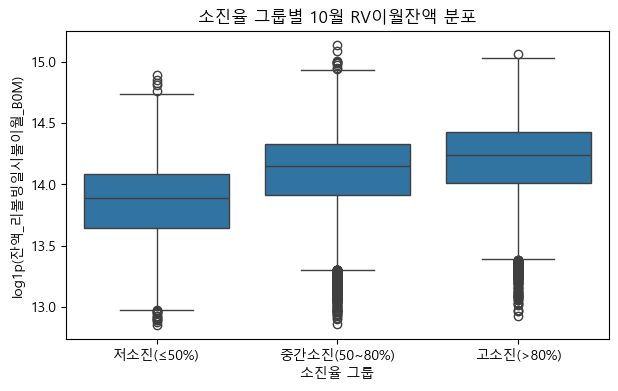

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_oct, x='소진율_그룹', y=np.log1p(df_oct['잔액_리볼빙일시불이월_B0M']))
plt.title('소진율 그룹별 10월 RV이월잔액 분포')
plt.xlabel('소진율 그룹')
plt.ylabel('log1p(잔액_리볼빙일시불이월_B0M)')
plt.show()


### * 한도 소진율이 높을수록 RV 이월잔액이 커지는 경향 확인 가능
### * "고소진 그룹 = RV 잔액이 많이 남을 위험이 높은 고객군"으로 볼수도 있을까? -> 구체화

------------------------------------------------------------------------------------------------------------------------------------

### 파생변수 만들어보기

In [85]:
df_eda = df_eda.copy()

#총 신용 이용금액
df_eda['이용금액_총합_B0M'] = df_eda['이용금액_신용_B0M'] + df_eda['이용금액_일시불_B0M']


#RV잔액 x 한도  <- 구체화를 위해 만들어본 변수
df_eda['RV잔액x소진율_B0M'] = (df_eda['잔액_리볼빙일시불이월_B0M'] * df_eda['잔액_신판평균한도소진율_r6m'])


#한도소진율 그룹 
bins = [0, 0.5, 0.8, 1.5]
labels = ['저소진(≤50%)', '중간소진(50~80%)', '고소진(>80%)']
df_eda['소진율_그룹'] = pd.cut(df_eda['잔액_신판평균한도소진율_r6m'],
                          bins=bins, labels=labels, include_lowest=True)




### * 'RV잔액x소진율_B0M'을 만든 근거 :

고객의 한도 사용 패턴을 기준으로 RV잔액의 상대적 규모를 파악하기 위해 (예를 들어 RV잔액이 평균이어도 한도소진율이 높다면 RV잔액의 상대적 규모가 크다고 판단)

RV잔액을 신판평균한도소진율로 곱한 파생변수를 생성했다.

고객별 유동성·신용사용 성향을 반영하여 RV잔액 증가 가능성을 파악해보고자 한다.


------------------------------------------------------------------------------------------------------------------------------------

### 간단한 통계치 확인

In [83]:
target = '잔액_리볼빙일시불이월_B0M'

feat_derived = [
    '이용금액_총합_B0M',
    'RV잔액x소진율_B0M',
]

df_eda[feat_derived + [target]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
).T

,count,mean,std,min,25%,50%,75%,90%,max
이용금액_총합_B0M,"83,403.00","1,170,756.19","920,874.31","-367,528.00","516,867.00","983,042.00","1,619,955.00","2,487,884.00","6,392,846.00"
RV잔액x소진율_B0M,"83,403.00","712,914.72","447,343.27",0.00,"352,087.30","665,340.12","1,026,208.20","1,326,728.40","3,027,196.44"
잔액_리볼빙일시불이월_B0M,"83,403.00","1,282,027.80","415,298.17","380,876.00","965,844.00","1,262,408.00","1,555,531.50","1,831,275.40","3,750,693.00"


In [77]:
# 상관계수
df_eda[['RV잔액x소진율_B0M', target]].corr()


,RV잔액x소진율_B0M,잔액_리볼빙일시불이월_B0M
RV잔액x소진율_B0M,1.00,0.83
잔액_리볼빙일시불이월_B0M,0.83,1.00


### 타겟 변수와 새 변수 사이의 관계 확인

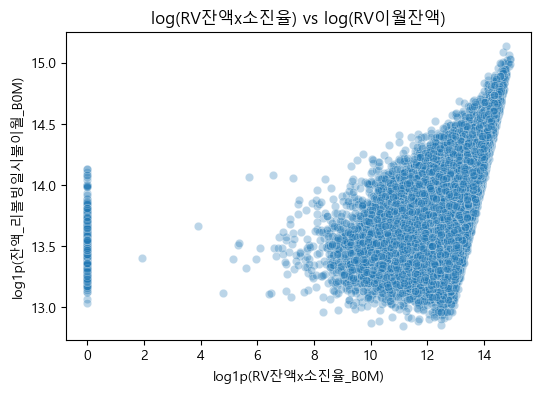

In [84]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=np.log1p(df_eda['RV잔액x소진율_B0M']),
    y=np.log1p(df_eda[target]),
    alpha=0.3
)
plt.title('log(RV잔액x소진율) vs log(RV이월잔액)')
plt.xlabel('log1p(RV잔액x소진율_B0M)')
plt.ylabel('log1p(잔액_리볼빙일시불이월_B0M)')
plt.show()


### *RV잔액이 많고, 한도 소진율도 높은 고객은 잔액 규모가 크다는 것을 알 수 있었다.
### *RV잔액이 커지면서 분산도 조금 넓어지지만, 전체적으로 모양이 정렬된 편인 것 같다,,

### 새로 만든 변수로도 3그룹으로 나눠서 RV 평균 잔액 확인

In [87]:
df_eda['파생_그룹'] = pd.qcut(df_eda['RV잔액x소진율_B0M'], 3, labels=['하', '중', '상'])

df_eda.groupby('파생_그룹')['잔액_리볼빙일시불이월_B0M'].mean()

C:\Users\jongy\AppData\Local\Temp\ipykernel_5088\2778364289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby('파생_그룹')['잔액_리볼빙일시불이월_B0M'].mean()


파생_그룹
하     944,650.80
중   1,215,240.81
상   1,686,191.78
Name: 잔액_리볼빙일시불이월_B0M, dtype: float64

<Axes: xlabel='파생_그룹', ylabel='잔액_리볼빙일시불이월_B0M'>

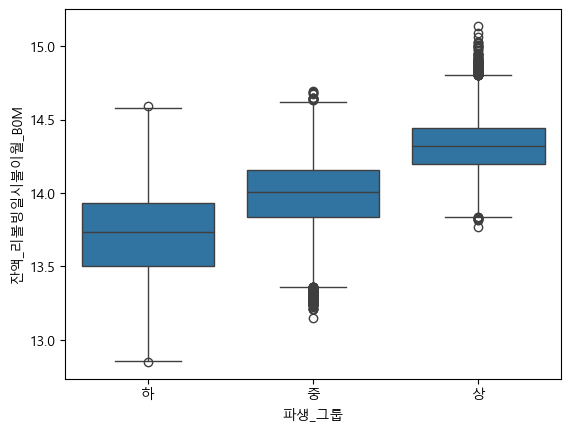

In [89]:
sns.boxplot(
    data=df_eda,
    x='파생_그룹',
    y=np.log1p(df_eda['잔액_리볼빙일시불이월_B0M'])
)


<Axes: xlabel='RV잔액x소진율_B0M', ylabel='Count'>

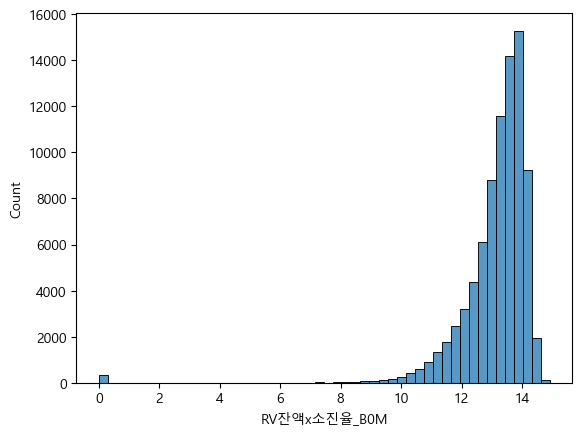

In [90]:
sns.histplot(np.log1p(df_eda['RV잔액x소진율_B0M']), bins=50)


------------------------------------------------------------------------------------------------------------------------------------

### 3. 간단한 가설 검증

### 가설 list

* 1. 한도소진율 그룹 별로 평균의 차이가 존재할 것이다. _ 앞에서 본 간단한 통계치 + 그림들로 경향성 파악 -> 통계적으로 유의미한 수준에 있는지 확인
* 2. RV잔액 × 한도소진율 (파생변수)가 클수록 RV잔액이 클 것이다.
* 3. 이용금액_신용_B0M이 클수록 RV잔액이 클 것이다. _ '신용을 사용이 많다 = 현금 여유 부족'으로 생각 했을 때 RV잔액이 클 것으로 예상 가능
* 4. RV약정청구율이 높은 고객은 이미 리스크가 높은 고객이라, RV잔액도 클 것이다. _ 유의미하다면 RV약정청구율도 좋은 변수가 될 것으로 예상
     
     (RV약정청구율은 카드사에서 고객에게 청구하는 금액 -> 고객이 처음 정한 비율 + 카드사 규정 상의 최저 납부금 등을 고려해 결정된 비율)

In [96]:
# 한도 소진율 그룹 -> 하  중  상 그룹으로 나누고 이 그룹들 간의 평균의 차이를 검증하기 위해 ANOVA 분석 진행

H0 : 세 그룹의 평균 RV잔액 (잔액_리볼빙일시불이월_B0M)은 동일하다.

H1 : 적어도 한 그룹의 평균은 다르다.

In [105]:
target = '잔액_리볼빙일시불이월_B0M'

g1 = df_eda.loc[df_eda['소진율_그룹'] == '저소진(≤50%)', target]
g2 = df_eda.loc[df_eda['소진율_그룹'] == '중간소진(50~80%)', target]
g3 = df_eda.loc[df_eda['소진율_그룹'] == '고소진(>80%)', target]


In [107]:
#ANOVA (정규성 / 등분산성 가정)

F, p = stats.f_oneway(g1, g2, g3)
print("ANOVA F:", F, "p-value:", p)


ANOVA F: 7773.924258242626 p-value: 0.0


In [109]:
#비모수
H, p_kw = stats.kruskal(g1, g2, g3)
print("Kruskal H:", H, "p-value:", p_kw)

Kruskal H: 13105.54552719553 p-value: 0.0


 ### 가설 1 검정 결과 : 
 p-value가 0.0으로 표시될 만큼 작다. -> 대립가설 채택

=> 적어도 한 그룹의 평균은 다르다. = 한도 소진율을 3 그룹으로 나눠 RV잔액 평균을 보는게 통계적으로 유의미하다.




-------------------------------------------------------------------------------------------------------------------------





### *** 시험기간이라 시간이 없어서 가설 검증은 1번만 진행했습니다! 죄송해요 ㅠㅠ
### *** 라이브 스터디 이전에 남은 것들도 해보겠습니다!